# About Dataset

**ANSUR II Databases: Ethnicity Prediction**

**1. Overview:**  
- ANSUR II (Anthropometric Survey of U.S. Army Personnel) is based on the results of a large-scale anthropometric (body measurements) study conducted by the U.S. Army in 2012.

**2. Dataset Content:**

- ANSUR II includes body measurements and ethnicity data for military personnel. The dataset contains over 100 measurements from various body parts of individuals. These measurements include details of the head, hand, foot, leg, arm, chest, and more.

- The dataset contains 93 directly measured anthropometric variables and 15 demographic/administrative variables described below.

- The male dataset includes a sample of 4,082 subjects.

- The ANSUR II female dataset contains a sample of 1,986 subjects.

- In addition to anthropometric and demographic data, the ANSUR II database also includes 3D full-body, foot, and head scans of the participants. However, these 3D data are not publicly available to respect the privacy of ANSUR II participants.

**3. Who Participated?**
- This database includes representatives from various ethnic groups and age groups of active-duty military personnel. The dataset contains measurements from both male and female participants.

**4. Relationship Between Measurement and Ethnicity:**
- Different ethnic groups may have distinct body structures due to genetic and environmental factors. This can be observed through variations in measurements such as leg length, head shape, hand, and foot dimensions.

**5. Modeling and Prediction:**
- Ethnicity prediction can be approached as a classification problem using the body measurements in the ANSUR II dataset.
- The algorithm to be used will learn the relationship between measurements and ethnicity and can be applied to new data to make ethnicity predictions.

**6. Importance and Application Areas of the Project:**
- Such research is used to analyze body measurements of military personnel to inform the design and production of military equipment, clothing, and other systems. Accurate measurements are crucial for the comfort, mobility, and overall safety of military personnel.

- Additionally, this has many potential commercial, industrial, and academic applications.

- Furthermore, for example, with laser readers and sensors, it might be possible to detect ethnicity upon entry at an airport.

DATA DICT:
https://data.world/datamil/ansur-ii-data-dictionary/workspace/file?filename=ANSUR+II+Databases+Overview.pdf
https://ph.health.mil/topics/workplacehealth/ergo/Pages/Anthropometric-Database.aspx

# Tasks

**Exploratory Data Analysis (EDA)**

- Import Libraries

- Load the Dataset

- Explore the Data

**Data Preprocessing**

- Scaling (if necessary)

- Split the dataframe for evaluation purposes

**Classification Algorithms**

- Apply Logistic Regression

- Apply SVM Classifier

- Apply Decision Tree Classifier

- Apply Random Forest Classifier

- Apply XGBoost Classifier

- Compare the Models

SMOTE

SHAP

# Importing Libraries

In [2]:
!pip install xgboost

ERROR: Exception:
Traceback (most recent call last):
  File "/Users/VG/Documents/TechProEducation/Data Science/Machine Learning/.venv/lib/python3.13/site-packages/pip/_internal/cli/base_command.py", line 107, in _run_wrapper
    status = _inner_run()
  File "/Users/VG/Documents/TechProEducation/Data Science/Machine Learning/.venv/lib/python3.13/site-packages/pip/_internal/cli/base_command.py", line 98, in _inner_run
    return self.run(options, args)
           ~~~~~~~~^^^^^^^^^^^^^^^
  File "/Users/VG/Documents/TechProEducation/Data Science/Machine Learning/.venv/lib/python3.13/site-packages/pip/_internal/cli/req_command.py", line 96, in wrapper
    return func(self, options, args)
  File "/Users/VG/Documents/TechProEducation/Data Science/Machine Learning/.venv/lib/python3.13/site-packages/pip/_internal/commands/install.py", line 487, in run
    if summary := installed_packages_summary(installed, env):
                  ~~~~~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^
  File "/Users/VG/Docu

In [1]:
# Standard library
import warnings

# Data handling
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Scikit-learn
import sklearn
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    PrecisionRecallDisplay,
    RocCurveDisplay,
    ConfusionMatrixDisplay,
    accuracy_score,
    average_precision_score,
    auc,
    classification_report,
    confusion_matrix,
    f1_score,
    get_scorer_names,
    log_loss,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GridSearchCV, cross_validate, train_test_split, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder
from yellowbrick.classifier import ClassPredictionError, ROCAUC
from itertools import cycle
from sklearn.preprocessing import label_binarize
from xgboost import XGBClassifier

# Settings
plt.rcParams["figure.figsize"] = (10, 6)
warnings.filterwarnings("ignore")
pd.set_option("display.float_format", lambda x: "%.3f" % x)

XGBoostError: 
XGBoost Library (libxgboost.dylib) could not be loaded.
Likely causes:
  * OpenMP runtime is not installed
    - vcomp140.dll or libgomp-1.dll for Windows
    - libomp.dylib for Mac OSX
    - libgomp.so for Linux and other UNIX-like OSes
    Mac OSX users: Run `brew install libomp` to install OpenMP runtime.

  * You are running 32-bit Python on a 64-bit OS

Error message(s): ["dlopen(/Users/VG/Documents/TechProEducation/Data Science/Machine Learning/.venv/lib/python3.13/site-packages/xgboost/lib/libxgboost.dylib, 0x0006): Library not loaded: @rpath/libomp.dylib\n  Referenced from: <1A0D8152-BF46-3BE0-B651-EE965C187777> /Users/VG/Documents/TechProEducation/Data Science/Machine Learning/.venv/lib/python3.13/site-packages/xgboost/lib/libxgboost.dylib\n  Reason: tried: '/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such

# EDA

**Retrieve data from the following links and create a data frame**

- Soldiers Male : https://query.data.world/s/h3pbhckz5ck4rc7qmt2wlknlnn7esr
- Soldiers Female : https://query.data.world/s/sq27zz4hawg32yfxksqwijxmpwmynq

- Drop unnecessary colums
- Drop DODRace class if value count below 500 (we assume that our data model can't learn if it is below 500)

In [ ]:
df_male = pd.read_csv("ANSUR II MALE Public.csv", encoding="cp1250")
df_female = pd.read_csv("ANSUR II FEMALE Public.csv", encoding="cp1250")

In [ ]:
df_male.head()

,subjectid,abdominalextensiondepthsitting,acromialheight,acromionradialelength,anklecircumference,axillaheight,balloffootcircumference,balloffootlength,biacromialbreadth,bicepscircumferenceflexed,...,Branch,PrimaryMOS,SubjectsBirthLocation,SubjectNumericRace,Ethnicity,DODRace,Age,Heightin,Weightlbs,WritingPreference
0,10027,266,1467,337,222,1347,253,202,401,369,...,Combat Arms,19D,North Dakota,1,NaN,1,41,71,180,Right hand
1,10032,233,1395,326,220,1293,245,193,394,338,...,Combat Support,68W,New York,1,NaN,1,35,68,160,Left hand
2,10033,287,1430,341,230,1327,256,196,427,408,...,Combat Support,68W,New York,2,NaN,2,42,68,205,Left hand
3,10092,234,1347,310,230,1239,262,199,401,359,...,Combat Service Support,88M,Wisconsin,1,NaN,1,31,66,175,Right hand
4,10093,250,1585,372,247,1478,267,224,435,356,...,Combat Service Support,92G,North Carolina,2,NaN,2,21,77,213,Right hand


In [ ]:
df_male.tail()

,subjectid,abdominalextensiondepthsitting,acromialheight,acromionradialelength,anklecircumference,axillaheight,balloffootcircumference,balloffootlength,biacromialbreadth,bicepscircumferenceflexed,...,Branch,PrimaryMOS,SubjectsBirthLocation,SubjectNumericRace,Ethnicity,DODRace,Age,Heightin,Weightlbs,WritingPreference
4077,29442,235,1353,312,216,1263,228,193,384,318,...,Combat Arms,11B,Colorado,51,Blackfoot Cherokee Choctaw,1,22,67,160,Right hand
4078,29443,247,1473,336,234,1346,253,196,428,374,...,Combat Arms,91B,Oklahoma,1,NaN,1,22,71,194,Right hand
4079,29447,264,1394,313,227,1280,245,193,407,367,...,Combat Arms,13B,Oklahoma,1,NaN,1,23,67,186,Right hand
4080,29451,203,1417,327,223,1314,250,196,419,365,...,Combat Arms,13P,Oklahoma,1,NaN,1,22,69,165,Right hand
4081,29452,327,1523,358,226,1408,269,225,442,379,...,Combat Arms,92Y,Oklahoma,1,NaN,1,38,73,218,Right hand


In [ ]:
df_female.head()

,SubjectId,abdominalextensiondepthsitting,acromialheight,acromionradialelength,anklecircumference,axillaheight,balloffootcircumference,balloffootlength,biacromialbreadth,bicepscircumferenceflexed,...,Branch,PrimaryMOS,SubjectsBirthLocation,SubjectNumericRace,Ethnicity,DODRace,Age,Heightin,Weightlbs,WritingPreference
0,10037,231,1282,301,204,1180,222,177,373,315,...,Combat Support,92Y,Germany,2,NaN,2,26,61,142,Right hand
1,10038,194,1379,320,207,1292,225,178,372,272,...,Combat Service Support,25U,California,3,Mexican,3,21,64,120,Right hand
2,10042,183,1369,329,233,1271,237,196,397,300,...,Combat Service Support,35D,Texas,1,NaN,1,23,68,147,Right hand
3,10043,261,1356,306,214,1250,240,188,384,364,...,Combat Service Support,25U,District of Columbia,8,Caribbean Islander,2,22,66,175,Right hand
4,10051,309,1303,308,214,1210,217,182,378,320,...,Combat Arms,42A,Texas,1,NaN,1,45,63,195,Right hand


In [ ]:
df_female.tail()

,SubjectId,abdominalextensiondepthsitting,acromialheight,acromionradialelength,anklecircumference,axillaheight,balloffootcircumference,balloffootlength,biacromialbreadth,bicepscircumferenceflexed,...,Branch,PrimaryMOS,SubjectsBirthLocation,SubjectNumericRace,Ethnicity,DODRace,Age,Heightin,Weightlbs,WritingPreference
1981,29501,285,1392,335,223,1297,252,196,368,299,...,Combat Support,42A,Texas,3,Mexican,3,51,67,180,Right hand
1982,29502,262,1324,301,202,1204,236,181,378,294,...,Combat Support,25U,Texas,3,Mexican,3,40,63,150,Right hand
1983,29503,260,1334,318,213,1259,234,183,363,332,...,Combat Support,42A,Texas,2,NaN,2,40,66,168,Right hand
1984,29511,205,1293,302,199,1207,213,163,376,276,...,Combat Support,92Y,Texas,3,Mexican,3,31,63,133,Right hand
1985,920103,238,1346,308,210,1256,236,188,361,285,...,Combat Support,92F,Texas,3,Mexican,3,27,66,132,Right hand


## Combine male and female dataset

In [ ]:
# subjectid and SubjectId are different on each dataset, we need to rename one of them to be able to concatenate the datasets.
df_female.columns.values[0] = "subjectid"

In [ ]:
# check if both datasets have the same column names
df_male.columns == df_female.columns

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True])

In [ ]:
df = pd.concat([df_male, df_female], axis=0, ignore_index=True)
df.head()

,subjectid,abdominalextensiondepthsitting,acromialheight,acromionradialelength,anklecircumference,axillaheight,balloffootcircumference,balloffootlength,biacromialbreadth,bicepscircumferenceflexed,...,Branch,PrimaryMOS,SubjectsBirthLocation,SubjectNumericRace,Ethnicity,DODRace,Age,Heightin,Weightlbs,WritingPreference
0,10027,266,1467,337,222,1347,253,202,401,369,...,Combat Arms,19D,North Dakota,1,NaN,1,41,71,180,Right hand
1,10032,233,1395,326,220,1293,245,193,394,338,...,Combat Support,68W,New York,1,NaN,1,35,68,160,Left hand
2,10033,287,1430,341,230,1327,256,196,427,408,...,Combat Support,68W,New York,2,NaN,2,42,68,205,Left hand
3,10092,234,1347,310,230,1239,262,199,401,359,...,Combat Service Support,88M,Wisconsin,1,NaN,1,31,66,175,Right hand
4,10093,250,1585,372,247,1478,267,224,435,356,...,Combat Service Support,92G,North Carolina,2,NaN,2,21,77,213,Right hand


- Accoruding to the data set description, following columns are self-reported. 
- Since these values ​​may mislead the model, these columns can be dropped from the data set.
    - SubjectNumericRace
    - Ethnicity
    - Heightin
    - Weightlbs

- Following columns were dropped from the data set because they were not considered necessary for race estimation.
    - subjectid
    - Date
    - Installation
    - Component
    - Branch
    - PrimaryMOS

In [ ]:
# before dropping, let's make a copy of the dataset
df_copy = df.copy()

In [ ]:
df_copy.drop(columns=["subjectid", "SubjectNumericRace", 
                 "Ethnicity", "Heightin", "Weightlbs", 
                 "Date", "Installation", "Component", ""
                 "Branch", "PrimaryMOS"
                 ],
                inplace=True
        )

In [ ]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6068 entries, 0 to 6067
Data columns (total 98 columns):
 #   Column                          Non-Null Count  Dtype 
---  ------                          --------------  ----- 
 0   abdominalextensiondepthsitting  6068 non-null   int64 
 1   acromialheight                  6068 non-null   int64 
 2   acromionradialelength           6068 non-null   int64 
 3   anklecircumference              6068 non-null   int64 
 4   axillaheight                    6068 non-null   int64 
 5   balloffootcircumference         6068 non-null   int64 
 6   balloffootlength                6068 non-null   int64 
 7   biacromialbreadth               6068 non-null   int64 
 8   bicepscircumferenceflexed       6068 non-null   int64 
 9   bicristalbreadth                6068 non-null   int64 
 10  bideltoidbreadth                6068 non-null   int64 
 11  bimalleolarbreadth              6068 non-null   int64 
 12  bitragionchinarc                6068 non-null   

In [ ]:
df_copy.isnull().sum().sum()

np.int64(0)

In [ ]:
df_copy.describe().T

,count,mean,std,min,25%,50%,75%,max
abdominalextensiondepthsitting,6068.000,246.469,37.400,155.000,219.000,242.000,271.000,451.000
acromialheight,6068.000,1406.161,79.091,1115.000,1350.000,1410.000,1462.000,1683.000
acromionradialelength,6068.000,327.374,20.720,249.000,313.000,328.000,341.250,393.000
anklecircumference,6068.000,224.891,16.052,156.000,214.000,225.000,235.000,293.000
axillaheight,6068.000,1299.609,72.022,1038.000,1249.000,1302.000,1349.000,1553.000
...,...,...,...,...,...,...,...,...
weightkg,6068.000,797.094,156.528,358.000,682.000,785.000,896.000,1442.000
wristcircumference,6068.000,169.003,13.125,124.000,159.000,170.000,179.000,216.000
wristheight,6068.000,830.060,47.651,672.000,797.000,830.000,863.000,1009.000
DODRace,6068.000,1.615,0.979,1.000,1.000,1.000,2.000,8.000


In [ ]:
df_copy["SubjectsBirthLocation"].value_counts().to_frame()

,count
SubjectsBirthLocation,
California,446
New York,420
Texas,397
Indiana,266
Oklahoma,221
...,...
Ivory Coast,1
Belarus,1
New Zealand,1


In [ ]:
# find out how many solders are in USA and how many are in other countries
USA = [
    "California", "New York", "Texas", "Indiana", "Oklahoma", "Illinois", "Florida", "Minnesota", "Michigan", 
    "Mississippi", "Georgia", "Alabama", "South Carolina", "North Carolina", "Ohio", "Louisiana", "Pennsylvania", 
    "Virginia", "Massachusetts", "Wisconsin", "New Jersey", "Arizona","Missouri","Colorado","Maryland","Tennessee","Kentucky","Washington","Kansas",
    "South Dakota", "Iowa", "Arkansas", "Connecticut", "Jamaica", "Nebraska", "Hawaii", "Utah", "West Virginia", "Nevada", "Idaho", "Rhode Island",
    "District of Columbia", "North Dakota","Maine", "Delaware", "New Mexico", "New Hampshire", "Vermont", "Montana", "Alaska", "Wyoming", 
    "US Virgin Islands", "United States"
]
usa_count = df_copy["SubjectsBirthLocation"].isin(USA).sum()
other_count = (~df_copy["SubjectsBirthLocation"].isin(USA)).sum()

print("USA count:", usa_count)
print("Other count:", other_count)

USA count: 5408
Other count: 660


In [ ]:
# Since there are only 660 soldier born in other contries, we can collect them in one category

df_copy["SubjectsBirthLocation"] = df_copy["SubjectsBirthLocation"].apply(
    lambda x: "USA" if x in USA else "Other"
)

df_copy["SubjectsBirthLocation"].value_counts().to_frame()

,count
SubjectsBirthLocation,
USA,5408
Other,660


In [ ]:
df_copy["DODRace"].value_counts().to_frame()

,count
DODRace,
1,3792
2,1298
3,679
4,188
6,59
5,49
8,3


1 = White
2 = Black
3 = Hispanic
4 = Asian
5 = Native American
6 = Pacific Islander
8 = Other

Since there are less than 200 soldier in race 4, 5, 6, and 8, we will call this group Other, which will give number 4
Our dataset will be following
1 = White
2 = Black
3 = Hispanic
4 = Other

In [ ]:
df_copy = df_copy[df_copy["DODRace"].isin([1, 2, 3])]
df_copy["DODRace"].value_counts().to_frame()

,count
DODRace,
1,3792
2,1298
3,679


## Data Visualization

### Gender Distribution

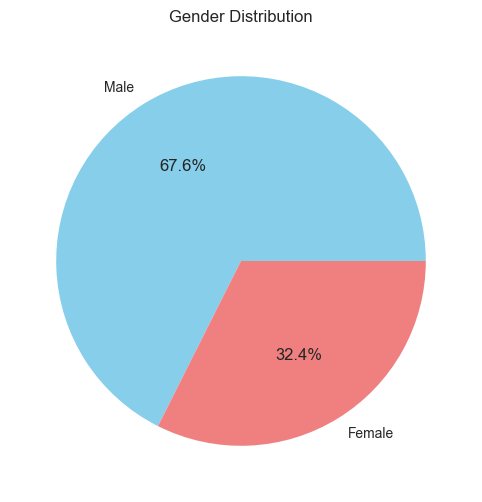

In [ ]:
gender_counts = df_copy['Gender'].value_counts()
gender_counts.plot.pie(autopct='%1.1f%%', colors=['skyblue', 'lightcoral'])
plt.title('Gender Distribution')
plt.ylabel('')
plt.show()

### Race Distribution

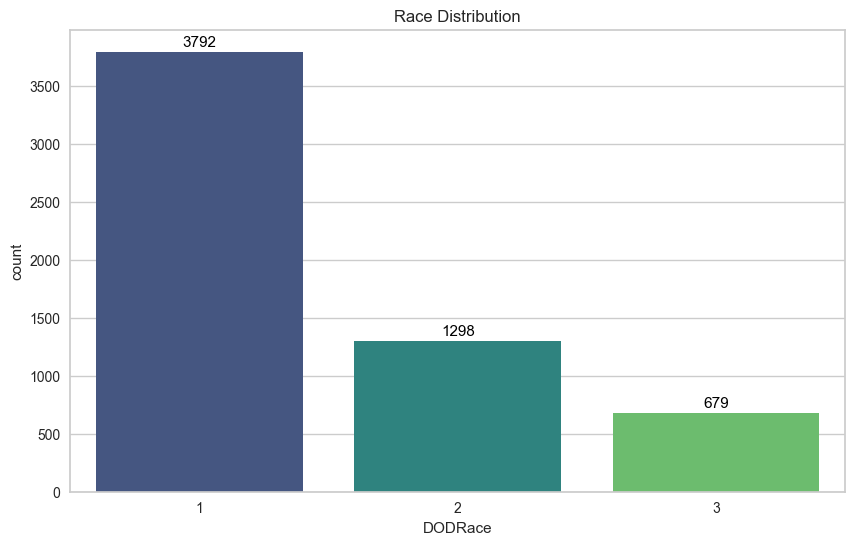

In [ ]:
ax = sns.countplot(x='DODRace', data=df_copy, palette='viridis')

for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge', fontsize=11, color='black', padding=2)
    
plt.title('Race Distribution')
plt.show()

### Height vs Weight with Gender

In [ ]:
# when weight and weight is calculated, it is multipled by 10
# we are going to devide weight and height by 10 to get the real values
df_copy['stature'] = df_copy['stature'] / 10
df_copy['weightkg'] = df_copy['weightkg'] / 10

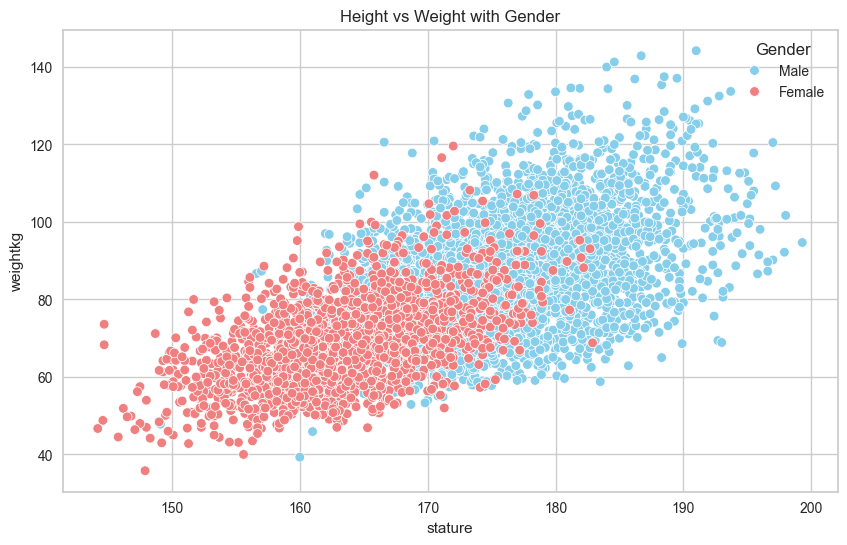

In [ ]:
sns.scatterplot(x='stature', y='weightkg', data=df_copy, hue='Gender', palette=['skyblue', 'lightcoral'])
plt.title('Height vs Weight with Gender')
plt.show()

# DATA Preprocessing
- In this step we divide our data to X(Features) and y(Target) then ,
- To train and evaluation purposes we create train and test sets,
- Lastly, scale our data if features not in same scale. Why?

In [ ]:
X = df_copy.drop(columns="DODRace")
y = df_copy.DODRace

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2,stratify=y, random_state=42)

In [ ]:
numeric_features = df_copy.drop("DODRace", axis =1).select_dtypes(include ="number").columns
numeric_features

Index(['abdominalextensiondepthsitting', 'acromialheight',
       'acromionradialelength', 'anklecircumference', 'axillaheight',
       'balloffootcircumference', 'balloffootlength', 'biacromialbreadth',
       'bicepscircumferenceflexed', 'bicristalbreadth', 'bideltoidbreadth',
       'bimalleolarbreadth', 'bitragionchinarc', 'bitragionsubmandibulararc',
       'bizygomaticbreadth', 'buttockcircumference', 'buttockdepth',
       'buttockheight', 'buttockkneelength', 'buttockpopliteallength',
       'calfcircumference', 'cervicaleheight', 'chestbreadth',
       'chestcircumference', 'chestdepth', 'chestheight', 'crotchheight',
       'crotchlengthomphalion', 'crotchlengthposterioromphalion', 'earbreadth',
       'earlength', 'earprotrusion', 'elbowrestheight', 'eyeheightsitting',
       'footbreadthhorizontal', 'footlength', 'forearmcenterofgriplength',
       'forearmcircumferenceflexed', 'forearmforearmbreadth',
       'forearmhandlength', 'functionalleglength', 'handbreadth',
      

In [ ]:
categorical_features =  df_copy.select_dtypes(include ="object").columns
categorical_features

Index(['Gender', 'SubjectsBirthLocation', 'WritingPreference'], dtype='object')

In [ ]:
column_transformer = make_column_transformer(
    (StandardScaler(), numeric_features),       
    (OneHotEncoder(), categorical_features)      
)
#Scaling numeric features and encoding categorical features

In [ ]:
def eval_metric(model, X_train, y_train, X_test, y_test):
    y_train_pred = model.predict(X_train)
    y_pred = model.predict(X_test)
    print("Test_Set")
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))
    print()
    print("Train_Set")
    print(confusion_matrix(y_train, y_train_pred))
    print(classification_report(y_train, y_train_pred))

# Modelling
- Fit the model with train dataset
- Get predict from vanilla model on both train and test sets to examine if there is over/underfitting   
- Apply GridseachCV for both hyperparemeter tuning and sanity test of our model.
- Use hyperparameters that you find from gridsearch and make final prediction and evaluate the result according to chosen metric.

## Logistic model

In [ ]:
operations = [ ("transformer",column_transformer), 
              ("logistic",LogisticRegression(class_weight='balanced',max_iter=10000,random_state=42))]

logistic_vanilla = Pipeline(steps=operations)

logistic_vanilla.fit(X_train,y_train)

Pipeline(steps=[('transformer',
                 ColumnTransformer(transformers=[('standardscaler',
                                                  StandardScaler(),
                                                  Index(['abdominalextensiondepthsitting', 'acromialheight',
       'acromionradialelength', 'anklecircumference', 'axillaheight',
       'balloffootcircumference', 'balloffootlength', 'biacromialbreadth',
       'bicepscircumferenceflexed', 'bicristalbreadth', 'bideltoidbreadth',
       'bim...
       'waistbacklength', 'waistbreadth', 'waistcircumference', 'waistdepth',
       'waistfrontlengthsitting', 'waistheightomphalion', 'weightkg',
       'wristcircumference', 'wristheight', 'Age'],
      dtype='object')),
                                                 ('onehotencoder',
                                                  OneHotEncoder(),
                                                  Index(['Gender', 'SubjectsBirthLocation', 'WritingPreference'], dtype='object'))])),
                ('logistic',
                 LogisticRegression(class_weight='balanced', max_iter=10000,
                                    random_state=42))])

In [ ]:
eval_metric(logistic_vanilla, X_train, y_train, X_test, y_test)

Test_Set
[[612  16 130]
 [ 10 234  16]
 [ 35   9  92]]
              precision    recall  f1-score   support

           1       0.93      0.81      0.87       758
           2       0.90      0.90      0.90       260
           3       0.39      0.68      0.49       136

    accuracy                           0.81      1154
   macro avg       0.74      0.79      0.75      1154
weighted avg       0.86      0.81      0.83      1154


Train_Set
[[2519   51  464]
 [  22  954   62]
 [  84   32  427]]
              precision    recall  f1-score   support

           1       0.96      0.83      0.89      3034
           2       0.92      0.92      0.92      1038
           3       0.45      0.79      0.57       543

    accuracy                           0.85      4615
   macro avg       0.78      0.85      0.79      4615
weighted avg       0.89      0.85      0.86      4615



In [ ]:
operations = [ ("transformer",column_transformer), 
              ("logistic",LogisticRegression(class_weight='balanced',max_iter=10000,random_state=42))]

logistic_vanilla = Pipeline(steps=operations)
param_grid = {
    'logistic__C': [0.1, 1, 10, 50, 100], 
    'logistic__penalty': ['l1', 'l2'], 
    'logistic__solver': ['liblinear', 'lbfgs'], 
    #'logistic__class_weight': [None, 'balanced'], 
    'logistic__max_iter': [50, 100, 200]
}
  
cv = StratifiedKFold(n_splits = 10)

logistic_grid = GridSearchCV(estimator = logistic_vanilla,
                             param_grid= param_grid,
                             cv = cv,
                             scoring='recall_weighted',
                             n_jobs= -1,
                             return_train_score= True)

logistic_grid.fit(X_train,y_train)

/Users/VG/Documents/TechProEducation/Data Science/Machine Learning/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/VG/Documents/TechProEducation/Data Science/Machine Learning/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for a

GridSearchCV(cv=StratifiedKFold(n_splits=10, random_state=None, shuffle=False),
             estimator=Pipeline(steps=[('transformer',
                                        ColumnTransformer(transformers=[('standardscaler',
                                                                         StandardScaler(),
                                                                         Index(['abdominalextensiondepthsitting', 'acromialheight',
       'acromionradialelength', 'anklecircumference', 'axillaheight',
       'balloffootcircumference', 'balloffootlength', 'bi...
                                                                         Index(['Gender', 'SubjectsBirthLocation', 'WritingPreference'], dtype='object'))])),
                                       ('logistic',
                                        LogisticRegression(class_weight='balanced',
                                                           max_iter=10000,
                                                           random_state=42))]),
             n_jobs=-1,
             param_grid={'logistic__C': [0.1, 1, 10, 50, 100],
                         'logistic__max_iter': [50, 100, 200],
                         'logistic__penalty': ['l1', 'l2'],
                         'logistic__solver': ['liblinear', 'lbfgs']},
             return_train_score=True, scoring='recall_weighted')

In [ ]:
logistic_grid.best_params_

{'logistic__C': 1,
 'logistic__max_iter': 50,
 'logistic__penalty': 'l2',
 'logistic__solver': 'liblinear'}

In [ ]:
logistic_grid.best_estimator_

Pipeline(steps=[('transformer',
                 ColumnTransformer(transformers=[('standardscaler',
                                                  StandardScaler(),
                                                  Index(['abdominalextensiondepthsitting', 'acromialheight',
       'acromionradialelength', 'anklecircumference', 'axillaheight',
       'balloffootcircumference', 'balloffootlength', 'biacromialbreadth',
       'bicepscircumferenceflexed', 'bicristalbreadth', 'bideltoidbreadth',
       'bim...
       'waistbacklength', 'waistbreadth', 'waistcircumference', 'waistdepth',
       'waistfrontlengthsitting', 'waistheightomphalion', 'weightkg',
       'wristcircumference', 'wristheight', 'Age'],
      dtype='object')),
                                                 ('onehotencoder',
                                                  OneHotEncoder(),
                                                  Index(['Gender', 'SubjectsBirthLocation', 'WritingPreference'], dtype='object'))])),
                ('logistic',
                 LogisticRegression(C=1, class_weight='balanced', max_iter=50,
                                    random_state=42, solver='liblinear'))])

In [ ]:
logistic_grid.best_score_

np.float64(0.874329286042952)

In [ ]:
y_pred_test = logistic_grid.predict(X_test)
y_pred_train = logistic_grid.predict(X_train)

In [ ]:
# Accuracy score
logistic_accuracy_test = accuracy_score(y_test, y_pred_test)
logistic_accuracy_train = accuracy_score(y_train, y_pred_train)

# F1 score 
logistic_f1_test = f1_score(y_test, y_pred_test, average='weighted')
logistic_f1_train = f1_score(y_train, y_pred_train, average='weighted')

# Recall score
logistic_recall_test = recall_score(y_test, y_pred_test, average='weighted')
logistic_recall_train = recall_score(y_train, y_pred_train, average='weighted')

logistic_accuracy_test, logistic_accuracy_train, logistic_f1_test, logistic_f1_train, logistic_recall_test, logistic_recall_train

(0.8570190641247833,
 0.8881906825568797,
 np.float64(0.8578480276254239),
 np.float64(0.8877731694444903),
 np.float64(0.8570190641247833),
 np.float64(0.8881906825568797))

In [ ]:
eval_metric(logistic_grid, X_train, y_train, X_test, y_test)

Test_Set
[[679  16  63]
 [ 16 238   6]
 [ 51  13  72]]
              precision    recall  f1-score   support

           1       0.91      0.90      0.90       758
           2       0.89      0.92      0.90       260
           3       0.51      0.53      0.52       136

    accuracy                           0.86      1154
   macro avg       0.77      0.78      0.78      1154
weighted avg       0.86      0.86      0.86      1154


Train_Set
[[2804   53  177]
 [  42  969   27]
 [ 167   50  326]]
              precision    recall  f1-score   support

           1       0.93      0.92      0.93      3034
           2       0.90      0.93      0.92      1038
           3       0.62      0.60      0.61       543

    accuracy                           0.89      4615
   macro avg       0.82      0.82      0.82      4615
weighted avg       0.89      0.89      0.89      4615



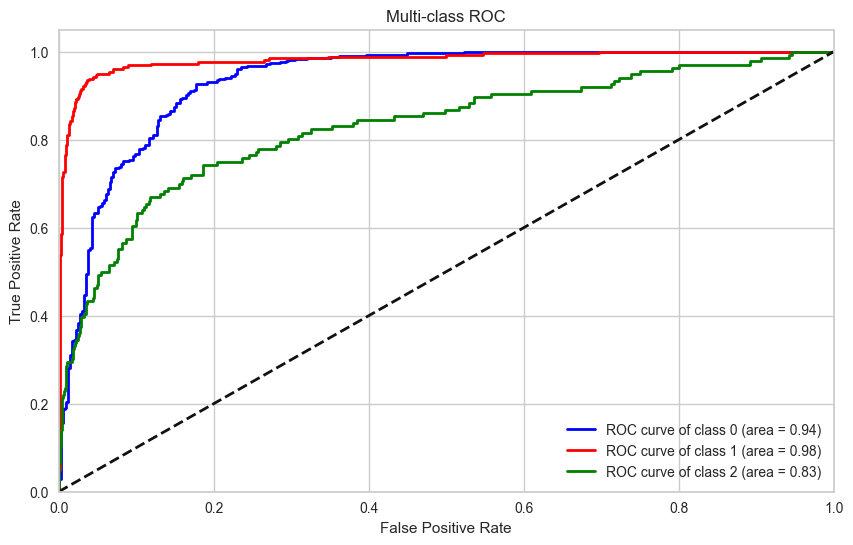

In [ ]:
# Converting the target variable to binary format
y_test_binarized = label_binarize(y_test, classes=np.unique(y_test))
n_classes = y_test_binarized.shape[1]

# Getting the prediction probabilities
y_pred_proba = logistic_grid.predict_proba(X_test)

# Calculating ROC curve and AUC for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_binarized[:, i], y_pred_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plotting ROC Curves
colors = cycle(['blue', 'red', 'green'])
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label='ROC curve of class {0} (area = {1:0.2f})'.format(i, roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-class ROC')
plt.legend(loc="lower right")
plt.show()

## SVM Classifier

In [ ]:
operations = [ ("transformer", column_transformer), 
              ("svc", SVC(random_state=42, probability=True))]

svc_vanilla = Pipeline(steps=operations)

svc_vanilla.fit(X_train,y_train)

Pipeline(steps=[('transformer',
                 ColumnTransformer(transformers=[('standardscaler',
                                                  StandardScaler(),
                                                  Index(['abdominalextensiondepthsitting', 'acromialheight',
       'acromionradialelength', 'anklecircumference', 'axillaheight',
       'balloffootcircumference', 'balloffootlength', 'biacromialbreadth',
       'bicepscircumferenceflexed', 'bicristalbreadth', 'bideltoidbreadth',
       'bim...
       'trochanterionheight', 'verticaltrunkcircumferenceusa',
       'waistbacklength', 'waistbreadth', 'waistcircumference', 'waistdepth',
       'waistfrontlengthsitting', 'waistheightomphalion', 'weightkg',
       'wristcircumference', 'wristheight', 'Age'],
      dtype='object')),
                                                 ('onehotencoder',
                                                  OneHotEncoder(),
                                                  Index(['Gender', 'SubjectsBirthLocation', 'WritingPreference'], dtype='object'))])),
                ('svc', SVC(probability=True, random_state=42))])

In [ ]:
eval_metric(svc_vanilla, X_train, y_train, X_test, y_test)

Test_Set
[[734  12  12]
 [ 22 234   4]
 [ 87  13  36]]
              precision    recall  f1-score   support

           1       0.87      0.97      0.92       758
           2       0.90      0.90      0.90       260
           3       0.69      0.26      0.38       136

    accuracy                           0.87      1154
   macro avg       0.82      0.71      0.73      1154
weighted avg       0.86      0.87      0.85      1154


Train_Set
[[3001   14   19]
 [  64  966    8]
 [ 291   39  213]]
              precision    recall  f1-score   support

           1       0.89      0.99      0.94      3034
           2       0.95      0.93      0.94      1038
           3       0.89      0.39      0.54       543

    accuracy                           0.91      4615
   macro avg       0.91      0.77      0.81      4615
weighted avg       0.91      0.91      0.89      4615



### SVC Model GridSearchCV

In [ ]:
param_grid = {
    'svc__C': [0.1, 0.5, 1],
    'svc__kernel': ['linear', 'rbf', 'sigmoid'],
    'svc__gamma': ["scale", "auto", 0.1, 1],
    'svc__degree': [1, 2, 3]
}

cv = StratifiedKFold(n_splits = 5)

In [ ]:
svc_grid_model = GridSearchCV(svc_vanilla,
                             param_grid,
                             cv = cv,
                             scoring = "recall_weighted",
                             n_jobs = -1,
                             verbose=2
                             )

svc_grid_model.fit(X_train, y_train)

Fitting 5 folds for each of 108 candidates, totalling 540 fits
[CV] END svc__C=0.1, svc__degree=1, svc__gamma=scale, svc__kernel=linear; total time=   1.7s
[CV] END svc__C=0.1, svc__degree=1, svc__gamma=scale, svc__kernel=linear; total time=   1.8s
[CV] END svc__C=0.1, svc__degree=1, svc__gamma=scale, svc__kernel=linear; total time=   1.9s
[CV] END svc__C=0.1, svc__degree=1, svc__gamma=scale, svc__kernel=linear; total time=   2.3s
[CV] END svc__C=0.1, svc__degree=1, svc__gamma=scale, svc__kernel=linear; total time=   2.3s
[CV] END svc__C=0.1, svc__degree=1, svc__gamma=scale, svc__kernel=rbf; total time=   4.0s
[CV] END svc__C=0.1, svc__degree=1, svc__gamma=scale, svc__kernel=sigmoid; total time=   2.6s
[CV] END svc__C=0.1, svc__degree=1, svc__gamma=scale, svc__kernel=sigmoid; total time=   2.6s
[CV] END svc__C=0.1, svc__degree=1, svc__gamma=scale, svc__kernel=sigmoid; total time=   2.7s
[CV] END svc__C=0.1, svc__degree=1, svc__gamma=scale, svc__kernel=rbf; total time=   5.0s
[CV] END s

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=None, shuffle=False),
             estimator=Pipeline(steps=[('transformer',
                                        ColumnTransformer(transformers=[('standardscaler',
                                                                         StandardScaler(),
                                                                         Index(['abdominalextensiondepthsitting', 'acromialheight',
       'acromionradialelength', 'anklecircumference', 'axillaheight',
       'balloffootcircumference', 'balloffootlength', 'bia...
      dtype='object')),
                                                                        ('onehotencoder',
                                                                         OneHotEncoder(),
                                                                         Index(['Gender', 'SubjectsBirthLocation', 'WritingPreference'], dtype='object'))])),
                                       ('svc',
                                        SVC(probability=True,
                                            random_state=42))]),
             n_jobs=-1,
             param_grid={'svc__C': [0.1, 0.5, 1], 'svc__degree': [1, 2, 3],
                         'svc__gamma': ['scale', 'auto', 0.1, 1],
                         'svc__kernel': ['linear', 'rbf', 'sigmoid']},
             scoring='recall_weighted', verbose=2)

In [ ]:
svc_grid_model.best_params_

{'svc__C': 0.1,
 'svc__degree': 1,
 'svc__gamma': 'scale',
 'svc__kernel': 'linear'}

In [ ]:
svc_grid_model.best_estimator_

Pipeline(steps=[('transformer',
                 ColumnTransformer(transformers=[('standardscaler',
                                                  StandardScaler(),
                                                  Index(['abdominalextensiondepthsitting', 'acromialheight',
       'acromionradialelength', 'anklecircumference', 'axillaheight',
       'balloffootcircumference', 'balloffootlength', 'biacromialbreadth',
       'bicepscircumferenceflexed', 'bicristalbreadth', 'bideltoidbreadth',
       'bim...
       'waistbacklength', 'waistbreadth', 'waistcircumference', 'waistdepth',
       'waistfrontlengthsitting', 'waistheightomphalion', 'weightkg',
       'wristcircumference', 'wristheight', 'Age'],
      dtype='object')),
                                                 ('onehotencoder',
                                                  OneHotEncoder(),
                                                  Index(['Gender', 'SubjectsBirthLocation', 'WritingPreference'], dtype='object'))])),
                ('svc',
                 SVC(C=0.1, degree=1, kernel='linear', probability=True,
                     random_state=42))])

In [ ]:
svc_grid_model.best_score_

np.float64(0.8808234019501624)

In [ ]:
y_pred_test = svc_grid_model.predict(X_test)
y_pred_train = svc_grid_model.predict(X_train)

In [ ]:
# Accuracy score
svc_accuracy_test = accuracy_score(y_test, y_pred_test)
svc_accuracy_train = accuracy_score(y_train, y_pred_train)

# F1 score
svc_f1_test = f1_score(y_test, y_pred_test, average='weighted')
svc_f1_train = f1_score(y_train, y_pred_train, average='weighted')

# Recall score
svc_recall_test = recall_score(y_test, y_pred_test, average='weighted')
svc_recall_train = recall_score(y_train, y_pred_train, average='weighted')

svc_accuracy_test, svc_accuracy_train, svc_f1_test, svc_f1_train, svc_recall_test, svc_recall_train

(0.8821490467937608,
 0.8966413867822318,
 np.float64(0.8720373682133581),
 np.float64(0.8878840105863531),
 np.float64(0.8821490467937608),
 np.float64(0.8966413867822318))

In [ ]:
eval_metric(svc_grid_model, X_train, y_train, X_test, y_test)

Test_Set
[[729  12  17]
 [ 22 233   5]
 [ 68  12  56]]
              precision    recall  f1-score   support

           1       0.89      0.96      0.92       758
           2       0.91      0.90      0.90       260
           3       0.72      0.41      0.52       136

    accuracy                           0.88      1154
   macro avg       0.84      0.76      0.78      1154
weighted avg       0.87      0.88      0.87      1154


Train_Set
[[2943   27   64]
 [  64  952   22]
 [ 259   41  243]]
              precision    recall  f1-score   support

           1       0.90      0.97      0.93      3034
           2       0.93      0.92      0.93      1038
           3       0.74      0.45      0.56       543

    accuracy                           0.90      4615
   macro avg       0.86      0.78      0.81      4615
weighted avg       0.89      0.90      0.89      4615



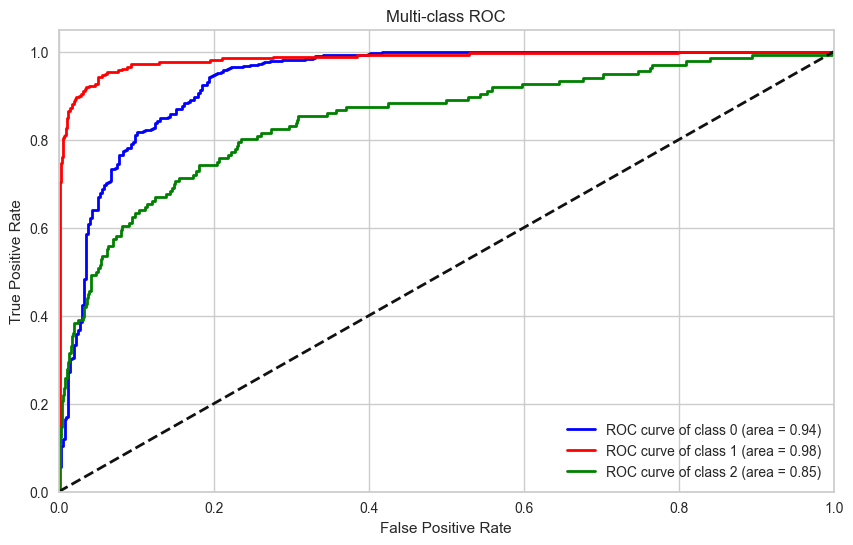

In [ ]:
# ROC Curves

y_test_binarized = label_binarize(y_test, classes=np.unique(y_test))
n_classes = y_test_binarized.shape[1]

y_pred_proba = svc_grid_model.predict_proba(X_test)

fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_binarized[:, i], y_pred_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

colors = cycle(['blue', 'red', 'green'])
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label='ROC curve of class {0} (area = {1:0.2f})'.format(i, roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-class ROC')
plt.legend(loc="lower right")
plt.show()


## Decision Tree Classifier

In [ ]:
operations = [ ("transformer", column_transformer), 
              ("svc", SVC(random_state=42, probability=True))]

svc_vanilla = Pipeline(steps=operations)

svc_vanilla.fit(X_train,y_train)





operations = [
    ("transformer", column_transformer),
    ("dt_clf", DecisionTreeClassifier(random_state=42))
]

dt_clf_model = Pipeline(steps=operations)

dt_clf_model.fit(X_train, y_train)
eval_metric(dt_clf_model, X_train, y_train, X_test, y_test)

Test_Set
[[592  75  91]
 [ 68 162  30]
 [ 78  19  39]]
              precision    recall  f1-score   support

           1       0.80      0.78      0.79       758
           2       0.63      0.62      0.63       260
           3       0.24      0.29      0.26       136

    accuracy                           0.69      1154
   macro avg       0.56      0.56      0.56      1154
weighted avg       0.70      0.69      0.69      1154


Train_Set
[[3034    0    0]
 [   0 1038    0]
 [   0    0  543]]
              precision    recall  f1-score   support

           1       1.00      1.00      1.00      3034
           2       1.00      1.00      1.00      1038
           3       1.00      1.00      1.00       543

    accuracy                           1.00      4615
   macro avg       1.00      1.00      1.00      4615
weighted avg       1.00      1.00      1.00      4615



### DT Model GridSearchCV

In [ ]:
param_grid = {
    'svc__C': [0.1, 0.5, 1],
    'svc__kernel': ['linear', 'rbf', 'sigmoid'],
    'svc__gamma': ["scale", "auto", 0.1, 1],
    'svc__degree': [1, 2, 3]
}

cv = StratifiedKFold(n_splits = 5)

In [ ]:
svc_grid_model = GridSearchCV(svc_vanilla,
                             param_grid,
                             cv = cv,
                             scoring = "recall_weighted",
                             n_jobs = -1,
                             verbose=2
                             )

svc_grid_model.fit(X_train, y_train)

In [ ]:
param_grid = {
    "DT_model__splitter": ["best", "random"],
    "DT_model__criterion": ["squared_error", "friedman_mse", "absolute_error"],
    "DT_model__max_depth": [2, 3,],
    "DT_model__min_samples_leaf": [1, 2, 3],
    "DT_model__min_samples_split": [2, 3],
    "DT_model__max_features": [4, 5, None]
}

In [ ]:
grid_model = GridSearchCV(estimator=pipe_model,
                          param_grid=param_grid,
                          scoring='neg_root_mean_squared_error',
                          cv=10,
                          n_jobs=-1,
                          return_train_score=True)

In [ ]:
operations = [ ("transformer", column_transformer), 
              ("svc", SVC(random_state=42, probability=True))]

## Random Forest Classifier

In [ ]:
operations = [ ("transformer",column_transformer), 
              ("RF_model",RandomForestClassifier(class_weight='balanced',random_state=42))]

rf_vanilla = Pipeline(steps= operations).fit(X_train,y_train)

In [ ]:
eval_metric(rf_vanilla, X_train, y_train, X_test, y_test)

Test_Set
[[745   8   5]
 [ 80 178   2]
 [109  10  17]]
              precision    recall  f1-score   support

           1       0.80      0.98      0.88       758
           2       0.91      0.68      0.78       260
           3       0.71      0.12      0.21       136

    accuracy                           0.81      1154
   macro avg       0.80      0.60      0.62      1154
weighted avg       0.81      0.81      0.78      1154


Train_Set
[[3034    0    0]
 [   0 1038    0]
 [   0    0  543]]
              precision    recall  f1-score   support

           1       1.00      1.00      1.00      3034
           2       1.00      1.00      1.00      1038
           3       1.00      1.00      1.00       543

    accuracy                           1.00      4615
   macro avg       1.00      1.00      1.00      4615
weighted avg       1.00      1.00      1.00      4615



### RF Model GridSearchCV

In [ ]:
param_grid = {
    'RF_model__n_estimators': [200, 300],
    'RF_model__max_features': ['sqrt', 4],
    'RF_model__max_depth': [None, 5, 10],
    'RF_model__min_samples_split': [2, 5],
    'RF_model__min_samples_leaf': [1, 2],
    'RF_model__max_samples': [0.8, 1.0]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [ ]:
operations = [
    ("transformer", column_transformer),
    ("RF_model", RandomForestClassifier(class_weight='balanced', random_state=42))
]

rf_vanilla = Pipeline(steps=operations)

rf_grid_model = GridSearchCV(
    rf_vanilla,
    param_grid,
    cv=cv,
    scoring="recall_weighted",
    n_jobs=-1,
    verbose=2
)

rf_grid_model.fit(X_train, y_train)

Fitting 5 folds for each of 96 candidates, totalling 480 fits
[CV] END RF_model__max_depth=None, RF_model__max_features=sqrt, RF_model__max_samples=0.8, RF_model__min_samples_leaf=1, RF_model__min_samples_split=2, RF_model__n_estimators=200; total time=   3.0s
[CV] END RF_model__max_depth=None, RF_model__max_features=sqrt, RF_model__max_samples=0.8, RF_model__min_samples_leaf=1, RF_model__min_samples_split=2, RF_model__n_estimators=200; total time=   3.0s
[CV] END RF_model__max_depth=None, RF_model__max_features=sqrt, RF_model__max_samples=0.8, RF_model__min_samples_leaf=1, RF_model__min_samples_split=2, RF_model__n_estimators=200; total time=   3.0s
[CV] END RF_model__max_depth=None, RF_model__max_features=sqrt, RF_model__max_samples=0.8, RF_model__min_samples_leaf=1, RF_model__min_samples_split=2, RF_model__n_estimators=200; total time=   3.1s
[CV] END RF_model__max_depth=None, RF_model__max_features=sqrt, RF_model__max_samples=0.8, RF_model__min_samples_leaf=1, RF_model__min_samples

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('transformer',
                                        ColumnTransformer(transformers=[('standardscaler',
                                                                         StandardScaler(),
                                                                         Index(['abdominalextensiondepthsitting', 'acromialheight',
       'acromionradialelength', 'anklecircumference', 'axillaheight',
       'balloffootcircumference', 'balloffootlength', 'biacro...
                                                                         Index(['Gender', 'SubjectsBirthLocation', 'WritingPreference'], dtype='object'))])),
                                       ('RF_model',
                                        RandomForestClassifier(class_weight='balanced',
                                                               random_state=42))]),
             n_jobs=-1,
             param_grid={'RF_model__max_depth': [None, 5, 10],
                         'RF_model__max_features': ['sqrt', 4],
                         'RF_model__max_samples': [0.8, 1.0],
                         'RF_model__min_samples_leaf': [1, 2],
                         'RF_model__min_samples_split': [2, 5],
                         'RF_model__n_estimators': [200, 300]},
             scoring='recall_weighted', verbose=2)

In [ ]:
rf_grid_model.best_params_

{'RF_model__max_depth': 10,
 'RF_model__max_features': 'sqrt',
 'RF_model__max_samples': 1.0,
 'RF_model__min_samples_leaf': 2,
 'RF_model__min_samples_split': 2,
 'RF_model__n_estimators': 300}

In [ ]:
rf_grid_model.best_estimator_

Pipeline(steps=[('transformer',
                 ColumnTransformer(transformers=[('standardscaler',
                                                  StandardScaler(),
                                                  Index(['abdominalextensiondepthsitting', 'acromialheight',
       'acromionradialelength', 'anklecircumference', 'axillaheight',
       'balloffootcircumference', 'balloffootlength', 'biacromialbreadth',
       'bicepscircumferenceflexed', 'bicristalbreadth', 'bideltoidbreadth',
       'bim...
       'waistfrontlengthsitting', 'waistheightomphalion', 'weightkg',
       'wristcircumference', 'wristheight', 'Age'],
      dtype='object')),
                                                 ('onehotencoder',
                                                  OneHotEncoder(),
                                                  Index(['Gender', 'SubjectsBirthLocation', 'WritingPreference'], dtype='object'))])),
                ('RF_model',
                 RandomForestClassifier(class_weight='balanced', max_depth=10,
                                        max_samples=1.0, min_samples_leaf=2,
                                        n_estimators=300, random_state=42))])

In [ ]:
rf_grid_model.best_score_

np.float64(0.8247020585048755)

In [ ]:
y_pred_test = rf_grid_model.predict(X_test)
y_pred_train = rf_grid_model.predict(X_train)

In [ ]:
# Accuracy score
rf_accuracy_test = accuracy_score(y_test, y_pred_test)
rf_accuracy_train = accuracy_score(y_train, y_pred_train)

# F1 score
rf_f1_test = f1_score(y_test, y_pred_test, average='weighted')
rf_f1_train = f1_score(y_train, y_pred_train, average='weighted')

# Recall score
rf_recall_test = recall_score(y_test, y_pred_test, average='weighted')
rf_recall_train = recall_score(y_train, y_pred_train, average='weighted')

rf_accuracy_test, rf_accuracy_train, rf_f1_test, rf_f1_train, rf_recall_test, rf_recall_train

(0.8119584055459272,
 0.9796316359696642,
 np.float64(0.8028206700588941),
 np.float64(0.9796627671112412),
 np.float64(0.8119584055459272),
 np.float64(0.9796316359696642))

In [ ]:
eval_metric(rf_grid_model, X_train, y_train, X_test, y_test)

Test_Set
[[687  25  46]
 [ 49 206   5]
 [ 78  14  44]]
              precision    recall  f1-score   support

           1       0.84      0.91      0.87       758
           2       0.84      0.79      0.82       260
           3       0.46      0.32      0.38       136

    accuracy                           0.81      1154
   macro avg       0.72      0.67      0.69      1154
weighted avg       0.80      0.81      0.80      1154


Train_Set
[[2993   10   31]
 [  25 1010    3]
 [  25    0  518]]
              precision    recall  f1-score   support

           1       0.98      0.99      0.99      3034
           2       0.99      0.97      0.98      1038
           3       0.94      0.95      0.95       543

    accuracy                           0.98      4615
   macro avg       0.97      0.97      0.97      4615
weighted avg       0.98      0.98      0.98      4615



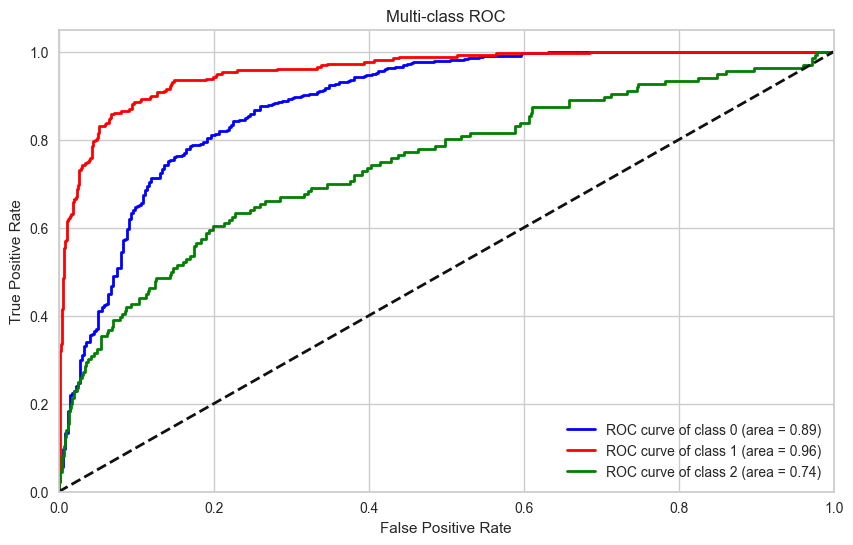

In [ ]:
# Plotting ROC Curves

y_test_binarized = label_binarize(y_test, classes=np.unique(y_test))
n_classes = y_test_binarized.shape[1]


y_pred_proba = rf_grid_model.predict_proba(X_test)


fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_binarized[:, i], y_pred_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])


colors = cycle(['blue', 'red', 'green'])
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label='ROC curve of class {0} (area = {1:0.2f})'.format(i, roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-class ROC')
plt.legend(loc="lower right")
plt.show()

## XGBoost

In [ ]:
operations = [ ("transformer",column_transformer), 
              ("xgb_model", XGBClassifier(random_state = 42))]

xgb_vanilla = Pipeline(steps = operations)

xgb_vanilla.fit(X_train, y_train)

NameError: name 'XGBClassifier' is not defined

In [ ]:
# Base XGBoost Model
operations = [("OrdinalEncoder", column_trans), ("XGB_model", XGBRegressor(random_state=101))]

pipe_model = Pipeline(steps=operations)

pipe_model.fit(X_train, y_train)

## Comparing Models

# Before the Deployment 
- Choose the model that works best based on your chosen metric
- For final step, fit the best model with whole dataset to get better performance.
- And your model ready to deploy, dump your model and scaler.

# SMOTE
https://machinelearningmastery.com/smote-oversampling-for-imbalanced-classification/

**SMOTE (Synthetic Minority Over-sampling Technique)**

**Purpose:**

SMOTE is a sampling technique used to balance imbalanced datasets. Imbalanced datasets refer to situations where one class has significantly more examples than others. In such datasets, the minority class (the class with fewer examples) is often overlooked, and the model tends to perform better in predicting the majority class. SMOTE aims to address this imbalance by generating new "synthetic" examples from the minority class.

**Use Cases:**

- **Credit Risk Assessment**: Fraud cases are usually imbalanced, meaning most transactions are legitimate, with only a few being fraudulent.
- **Medical Diagnosis**: For example, if a disease is rare, there will be an imbalance between healthy and diseased samples.
- **Customer Churn Analysis**: Most customers continue using a service, while only a few leave.
- **Anomaly Detection**: Normal situations are more common, whereas anomalies (e.g., security breaches) are rare.

**Importance for Unbalanced Data:**

Imbalanced datasets can negatively affect the performance of classification models. A model might perform well in predicting the majority class but often neglects the minority class. This can be problematic, especially if the minority class is more important (e.g., fraud detection, diagnosing rare diseases). SMOTE is used to mitigate such problems.

**How It Works:**

1. A random sample from the minority class is selected.
2. The k nearest neighbors of this sample are computed.
3. One of the k nearest neighbors is randomly selected.
4. A random interpolation factor* is generated.
5. Using this factor, a new "synthetic" sample is created.

**Usage:**

In Python, SMOTE is commonly used with the imbalanced-learn library.

*The interpolation factor is a weight used in the SMOTE algorithm when creating new "synthetic" samples. The idea is to generate a new sample between a randomly selected minority class sample and its k nearest neighbors. The interpolation factor determines how "close" the new sample will be to either of the two samples. It enhances the flexibility of the SMOTE algorithm, helping to spread the minority class samples over a wider range and improving the model's ability to generalize.

#  SHAP

**SHAP (SHapley Additive exPlanations)**

**What is it?**

SHAP is a tool used to explain the predictions of machine learning models. SHAP values measure the impact of each feature on a prediction. These values are based on Shapley values, a mathematical theory from cooperative game theory.

**Purpose:**
- **Model Interpretability**: Understanding which features most influence predictions.
- **Feature Selection**: Identifying the most important features to reduce model complexity.
- **Audit and Compliance**: Explaining model decisions and meeting regulatory requirements.
- **Model Improvement**: Understanding where the model performs well or poorly.

**Applications:**
- **Credit Scoring**: Understanding which factors affect an individual's credit score.
- **Healthcare**: Identifying which medical features are important for predicting diseases.
- **Marketing**: Understanding factors that influence customer behavior.
- **Natural Language Processing**: Understanding which words or features are important in tasks like text classification or sentiment analysis.

**Importance in Unbalanced Data Sets:**

In unbalanced datasets, the model can be biased toward the majority class. SHAP is useful in such cases because it helps identify why the model might be misclassifying the minority class and provides insights into how different features affect the model's predictions for both majority and minority classes. https://towardsdatascience.com/shap-explain-any-machine-learning-model-in-python-24207127cad7

- SHAP shows how much each feature contributes to predictions on a per-observation basis or across the entire dataset, indicating the impact of each feature when predicting classes.

- For instance, if we select features specifically related to the Hispanic class and perform feature selection only on those features, our scores might improve even with fewer observations.

- This approach is different from the feature importance analysis we did previously.

# <p style="background-color:green;font-family:newtimeroman;font-size:150%;color:white;text-align:center;border-radius:20px 20px;"><b>Thanks - Hoping it will be useful</b></p>
![](https://www.techproeducation.com/logo/headerlogo.svg)

<b>If you want to be the first to know about our latest updates, please don't forget to follow us!</b>[YouTube](https://www.youtube.com/c/techproeducation) | [Instagram](https://www.instagram.com/techproeducation) | [Facebook](https://www.facebook.com/techproeducation) | [Telegram](https://t.me/joinchat/HH2qRvA-ulh4OWbb) | [WhatsApp](https://api.whatsapp.com/send/?phone=%2B15853042959&text&type=phone_number&app_absent=0) | [LinkedIn](https://www.linkedin.com/company/techproeducation/mycompany/) |